# Informe 3: Modelos de Regresión

- **Asignatura:** Inteligencia Artificial
- **Grupo:** 03
- **Integrantes:** Bautista De la Cruz Claudia Daniela, Carrascal Castro Priscila Maria, Ccahuana Quiñones Judith Valeria, Gil Sixi Alberto Luis, Medrano Ayma Nikol Arlet, Rosales Trinidad Jeanmarco Miguel, Saire Tello Fernando José

## Empresa: AndinaSense

AndinaSense es una empresa de agricultura de precisión que brinda servicios de monitoreo a agroexportadoras de arándano en los valles de la costa norte del Perú (La Libertad, Lambayeque e Ica). Mediante sensores instalados en las parcelas, registra las condiciones de suelo, clima y manejo de cada una. Con miles de parcelas bajo monitoreo, necesita agruparlas en perfiles que permitan un manejo diferenciado y eficiente, en lugar de tratarlas todas por igual.

**Objetivo del informe:** Predecir el rendimiento de la cosecha de una parcela de
arándano (`rendimiento_kg_ha`, en kg por hectárea) a partir de sus condiciones de
suelo, clima y manejo, usando modelos de regresión supervisada.

**Pregunta de negocio:** ¿Cuánto rendirá una parcela según sus condiciones medidas
por los sensores?

**Por qué aporta valor:** Anticipar el rendimiento permite a AndinaSense planificar
la logística de cosecha, proyectar ingresos por valle y priorizar la atención de las
parcelas de bajo desempeño antes de que el problema se refleje en la producción.

## Generación y carga del dataset

El dataset `andinasense_parcelas.csv` es sintético y propio del grupo. Contiene 1500 parcelas (filas) y 13 variables (columnas), con mezcla de numéricas y categóricas. La variable objetivo continua es `rendimiento_kg_ha` y la categórica es `calidad_cosecha` (Baja, Media, Alta).

Generación (reproducible con semilla SEED = 42):

- Las parcelas provienen de 4 zonas agroecológicas latentes con proporciones controladas (Óptima 35%, Estrés Hídrico 25%, Desbalance de pH 20%, Multi-estrés Leve 20%). La zona se usa solo para generar y no aparece como columna.
- Cada zona tiene un perfil de medias por variable de suelo, clima y manejo, con dispersión calibrada para un solapamiento realista (correlaciones y ruido, no grupos perfectos).
- `rendimiento_kg_ha` se deriva de una función de respuesta agronómica con penalización cuadrática (óptimo de temperatura 20 °C y de pH 5.5) más ruido gaussiano; `calidad_cosecha` se obtiene por terciles del rendimiento.
- Se introdujeron nulos y valores atípicos intencionales en las columnas de sensores para exigir tratamiento en el preprocesamiento.

El script generador completo, reproducible con la misma semilla, está en el repositorio del proyecto (carpeta `generador_dataset`). Este notebook no regenera los datos: solo carga el CSV en la siguiente celda.

## 1. Configuración e Importación de Librerías

In [1]:
# ── Celda 1: Importaciones ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
print('Librerías importadas correctamente.')
print(f'Versión scikit-learn: {__import__("sklearn").__version__}')

Librerías importadas correctamente.
Versión scikit-learn: 1.4.2


## 2. Carga y Análisis Exploratorio de Datos (EDA)

El dataset `andinasense_parcelas.csv` contiene 1500 parcelas de arándano monitoreadas.
Cada fila es una parcela con sus variables de suelo, clima y manejo, su rendimiento
obtenido y la calidad final de cosecha. En este informe la variable objetivo es
`rendimiento_kg_ha` (continua).

In [2]:
# ── Celda 2a: Cargar el dataset ─────────────────────────────────────────
df = pd.read_csv('andinasense_parcelas.csv')
print('=== DIMENSIONES ===')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print('\n=== PRIMERAS 5 FILAS ===')
df.head()

=== DIMENSIONES ===
Filas: 1500 | Columnas: 13

=== PRIMERAS 5 FILAS ===


,id_parcela,region,variedad,superficie_ha,temp_promedio,humedad_suelo,ph_suelo,horas_sol,riego_mm,fertilizante_kg,densidad_plantas,rendimiento_kg_ha,calidad_cosecha
0,PARC-00001,Lambayeque,Emerald,10.55,19.5,55.5,6.72,9.6,523.0,282.0,4443.0,8476.0,Baja
1,PARC-00002,Lambayeque,Biloxi,4.33,22.0,42.1,5.48,8.4,698.0,166.0,4204.0,8542.0,Baja
2,PARC-00003,La Libertad,Ventura,5.04,21.0,40.7,6.22,7.7,619.0,253.0,3547.0,9270.0,Alta
3,PARC-00004,La Libertad,Rocio,7.19,20.4,52.1,6.63,9.2,507.0,277.0,4229.0,8624.0,Media
4,PARC-00005,Lambayeque,Biloxi,2.76,20.8,56.9,5.33,9.2,592.0,201.0,3778.0,9033.0,Media


In [3]:
# ── Celda 2b: Información general y tipos de datos ───────────────────────
print(df.info())
print('\n=== VALORES NULOS POR COLUMNA ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_parcela         1500 non-null   object 
 1   region             1500 non-null   object 
 2   variedad           1500 non-null   object 
 3   superficie_ha      1500 non-null   float64
 4   temp_promedio      1500 non-null   float64
 5   humedad_suelo      1440 non-null   float64
 6   ph_suelo           1455 non-null   float64
 7   horas_sol          1463 non-null   float64
 8   riego_mm           1500 non-null   float64
 9   fertilizante_kg    1500 non-null   float64
 10  densidad_plantas   1500 non-null   float64
 11  rendimiento_kg_ha  1500 non-null   float64
 12  calidad_cosecha    1500 non-null   object 
dtypes: float64(9), object(4)
memory usage: 152.5+ KB
None

=== VALORES NULOS POR COLUMNA ===
humedad_suelo    60
ph_suelo         45
horas_sol        37
dtype: int64


In [4]:
# ── Celda 2c: Estadísticas descriptivas ─────────────────────────────────
df.describe().round(2)

,superficie_ha,temp_promedio,humedad_suelo,ph_suelo,horas_sol,riego_mm,fertilizante_kg,densidad_plantas,rendimiento_kg_ha
count,1500.00,1500.00,1440.00,1455.00,1463.00,1500.00,1500.00,1500.00,1500.00
mean,7.03,21.19,52.31,5.95,8.75,600.58,219.99,3937.51,8795.93
std,2.94,1.42,10.51,0.65,0.90,73.16,39.60,349.17,523.58
min,2.00,17.60,25.30,4.72,5.80,442.00,106.00,2831.00,6740.00
25%,4.50,20.10,43.90,5.50,8.20,546.00,193.00,3695.00,8439.00
50%,7.04,21.10,53.60,5.73,8.90,586.00,218.00,3954.50,8832.00
75%,9.60,22.32,60.00,6.30,9.40,653.00,247.00,4184.25,9172.75
max,11.99,25.50,120.60,11.72,10.90,830.00,362.00,5059.00,10131.00


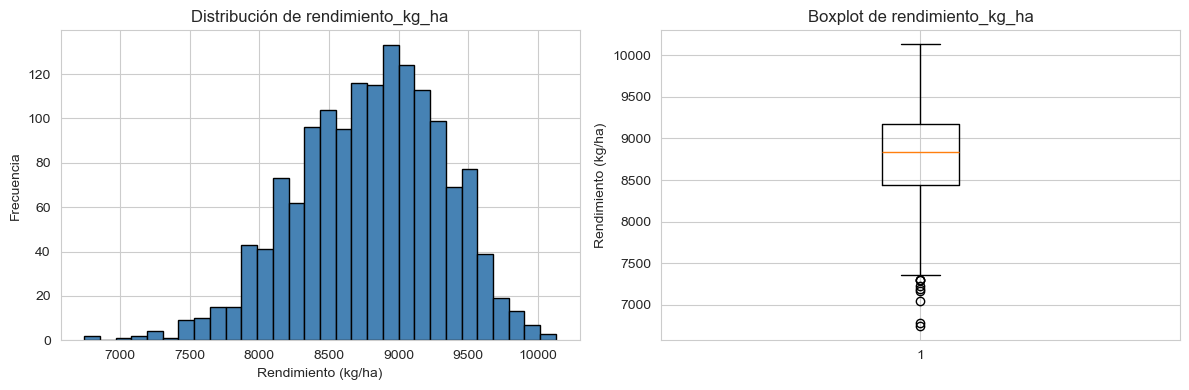

Media:        8,796 kg/ha
Mediana:      8,832 kg/ha
Std:            524 kg/ha


In [5]:
# ── Celda 2d: Distribución de la variable objetivo (rendimiento_kg_ha) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['rendimiento_kg_ha'], bins=30, edgecolor='black', color='steelblue')
axes[0].set_title('Distribución de rendimiento_kg_ha')
axes[0].set_xlabel('Rendimiento (kg/ha)')
axes[0].set_ylabel('Frecuencia')
axes[1].boxplot(df['rendimiento_kg_ha'])
axes[1].set_title('Boxplot de rendimiento_kg_ha')
axes[1].set_ylabel('Rendimiento (kg/ha)')
plt.tight_layout()
plt.savefig('eda_rendimiento.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Media:   {df["rendimiento_kg_ha"].mean():>10,.0f} kg/ha')
print(f'Mediana: {df["rendimiento_kg_ha"].median():>10,.0f} kg/ha')
print(f'Std:     {df["rendimiento_kg_ha"].std():>10,.0f} kg/ha')

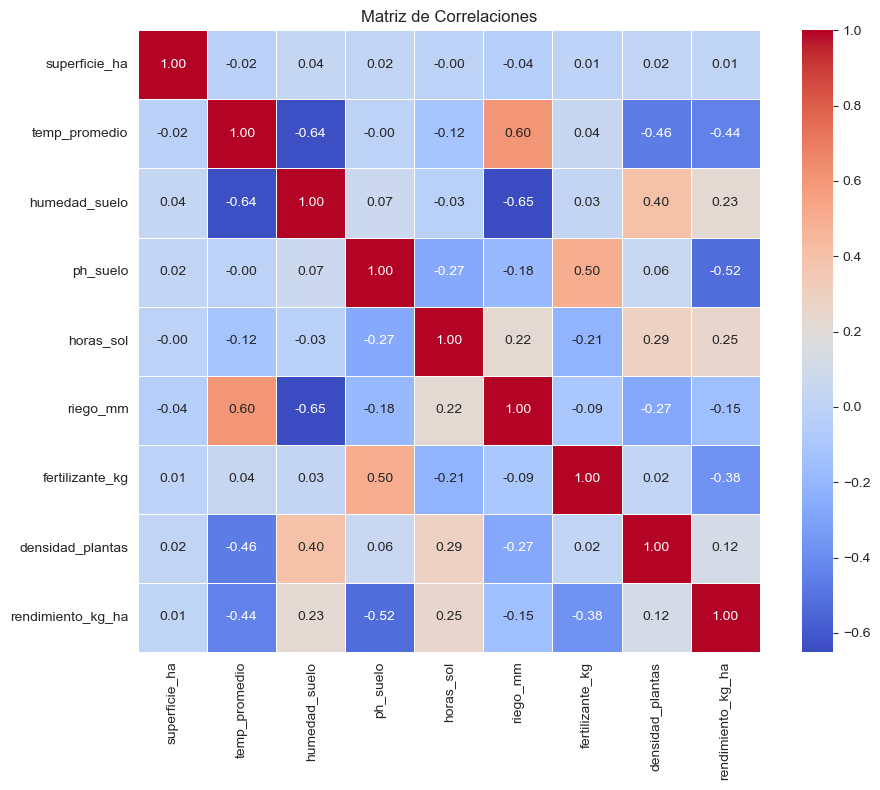


Correlación con rendimiento_kg_ha:
rendimiento_kg_ha    1.000
horas_sol            0.247
humedad_suelo        0.226
densidad_plantas     0.117
superficie_ha        0.012
riego_mm            -0.149
fertilizante_kg     -0.375
temp_promedio       -0.438
ph_suelo            -0.524
Name: rendimiento_kg_ha, dtype: float64


In [6]:
# ── Celda 2e: Mapa de calor de correlaciones (solo numéricas) ───────────
num_cols = df.select_dtypes(include='number')
corr = num_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Matriz de Correlaciones')
plt.tight_layout()
plt.savefig('eda_correlaciones.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nCorrelación con rendimiento_kg_ha:')
print(corr['rendimiento_kg_ha'].sort_values(ascending=False).round(3))

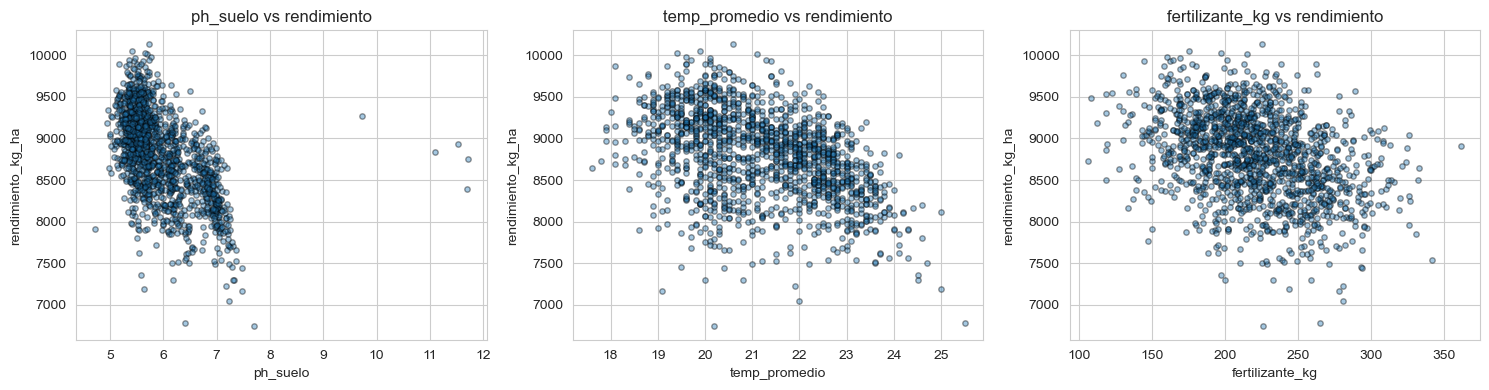

Variables más correlacionadas con el rendimiento: ['ph_suelo', 'temp_promedio', 'fertilizante_kg']


In [7]:
# ── Celda 2f: Scatter de las 3 variables más correlacionadas ────────────
top_vars = (corr['rendimiento_kg_ha']
            .drop('rendimiento_kg_ha').abs()
            .sort_values(ascending=False).head(3).index.tolist())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, top_vars):
    ax.scatter(df[var], df['rendimiento_kg_ha'], alpha=0.4, edgecolors='k', s=15)
    ax.set_xlabel(var)
    ax.set_ylabel('rendimiento_kg_ha')
    ax.set_title(f'{var} vs rendimiento')
plt.tight_layout()
plt.savefig('eda_scatter_top3.png', dpi=120, bbox_inches='tight')
plt.show()
print('Variables más correlacionadas con el rendimiento:', top_vars)

### Observaciones del análisis exploratorio (EDA)

- Las variables con mayor correlación lineal en valor absoluto con rendimiento_kg_ha son ph_suelo (≈ −0.52), temp_promedio (≈ −0.44) y fertilizante_kg (≈ −0.38), seguidas de horas_sol (≈ +0.25) y humedad_suelo (≈ +0.23). El resto (superficie_ha, densidad_plantas, riego_mm) muestra correlaciones lineales débiles.
- El signo de las correlaciones de pH y temperatura debe leerse con cuidado. Ambas tienen un valor ideal (≈ 5.5 de pH y ≈ 20 °C): el rendimiento sube hasta ese punto y baja al alejarse en cualquier dirección. Como la mayoría de las parcelas está por encima del óptimo, el coeficiente lineal sale negativo, pero la relación real es una campana (U invertida), no una recta descendente.
- Los scatter de la Celda 2f lo confirman: en ph_suelo y temp_promedio la nube de puntos sigue una curva con un máximo intermedio, no una línea. Por eso la correlación lineal subestima la verdadera influencia de estas variables.
- horas_sol y humedad_suelo sí muestran una tendencia lineal y positiva coherente con la agronomía: más sol y humedad adecuada implican más rendimiento.
- La correlación negativa de fertilizante_kg y riego_mm es contraintuitiva a primera vista; se explica por el ruido introducido a propósito y por confusión con otras variables, ya que parcelas fuera del óptimo de pH o temperatura recibieron más insumos sin recuperar rendimiento.

## 3. Preprocesamiento de Datos

Se descarta el identificador, se separan predictoras y objetivo, se divide en
entrenamiento y prueba (80/20) y se construye un **Pipeline** que imputa los
valores faltantes (sensores con lecturas perdidas), escala las numéricas y
codifica las categóricas. El uso de Pipeline evita el *data leakage*: la
transformación se aprende solo con los datos de entrenamiento.

In [8]:
# ── Celda 3a: Separar predictoras y objetivo ────────────────────────────
# 'id_parcela' es identificador, no predictor.
# 'calidad_cosecha' es la variable objetivo del Informe 4 (clasificación): se excluye aquí.
df_mod = df.drop(columns=['id_parcela', 'calidad_cosecha'])

X = df_mod.drop(columns=['rendimiento_kg_ha'])
y = df_mod['rendimiento_kg_ha']

col_numericas = X.select_dtypes(include='number').columns.tolist()
col_categoricas = X.select_dtypes(exclude='number').columns.tolist()
print('Columnas numéricas:', col_numericas)
print('Columnas categóricas:', col_categoricas)

Columnas numéricas: ['superficie_ha', 'temp_promedio', 'humedad_suelo', 'ph_suelo', 'horas_sol', 'riego_mm', 'fertilizante_kg', 'densidad_plantas']
Columnas categóricas: ['region', 'variedad']


In [9]:
# ── Celda 3b: División entrenamiento / prueba (80/20) ───────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (1200, 10) | X_test: (300, 10)


In [10]:
# ── Celda 3c: Pipeline de preprocesamiento ──────────────────────────────
# Numéricas: imputar nulos con la mediana + escalar.
# Categóricas (region, variedad): imputar con la moda + OneHotEncoder.
prep_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
prep_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', prep_num, col_numericas),
    ('cat', prep_cat, col_categoricas)
])
print('Pipeline de preprocesamiento definido correctamente.')

Pipeline de preprocesamiento definido correctamente.


## 4. Modelos de Regresión

Se entrenan, según lo solicitado: Regresión Lineal Múltiple (OLS) como baseline,
Regresión Polinómica, Ridge (L2), Lasso (L1) y un modelo avanzado,
Gradient Boosting Regressor. Cada modelo se envuelve en un Pipeline con el
preprocesador, de modo que la imputación y el escalado se apliquen correctamente.

In [11]:
# ── Celda 4a: Regresión Lineal Múltiple (OLS) — BASELINE ────────────────
pipe_ols = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
pipe_ols.fit(X_train, y_train)
y_pred_ols = pipe_ols.predict(X_test)

mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)
print('=== Regresión Lineal Múltiple (OLS) ===')
print(f'  MSE : {mse_ols:>15,.2f}')
print(f'  RMSE: {rmse_ols:>15,.2f}')
print(f'  MAE : {mae_ols:>15,.2f}')
print(f'  R²  : {r2_ols:>15.4f}')

=== Regresión Lineal Múltiple (OLS) ===
  MSE :      133,542.19
  RMSE:          365.43
  MAE :          288.22
  R²  :          0.5186


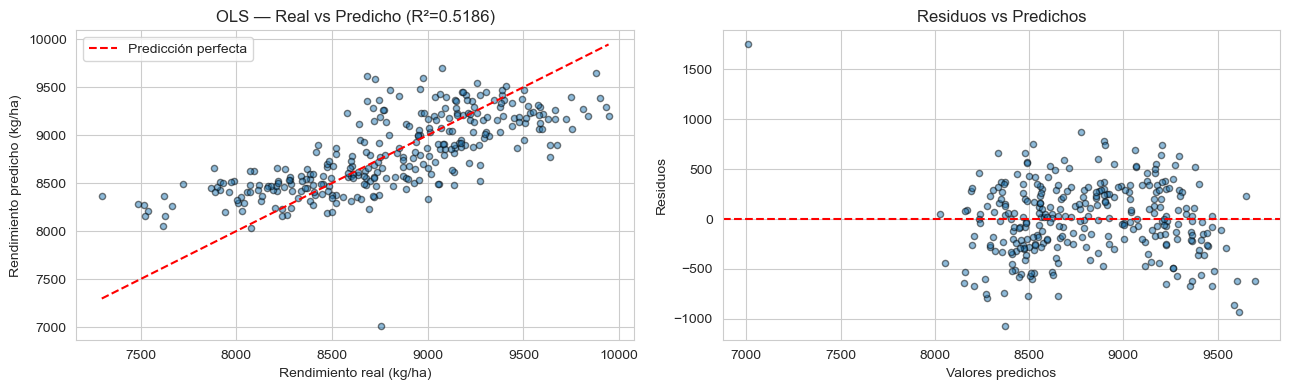

Media de residuos: -3.4262 (idealmente ≈ 0)


In [12]:
# ── Celda 4b: Gráfico real vs predicho y residuos (OLS) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_test, y_pred_ols, alpha=0.5, edgecolors='k', s=20)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Rendimiento real (kg/ha)')
axes[0].set_ylabel('Rendimiento predicho (kg/ha)')
axes[0].set_title(f'OLS — Real vs Predicho (R²={r2_ols:.4f})')
axes[0].legend()

residuos = y_test - y_pred_ols
axes[1].scatter(y_pred_ols, residuos, alpha=0.5, edgecolors='k', s=20)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Valores predichos')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos vs Predichos')
plt.tight_layout()
plt.savefig('ols_diagnostico.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Media de residuos: {residuos.mean():.4f} (idealmente ≈ 0)')

In [13]:
# ── Celda 4c: Regresión Polinómica (comparar grados 1, 2 y 3) ───────────
resultados_poly = {}
for grado in [1, 2, 3]:
    pipe = Pipeline([
        ('pre', preprocessor),
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('reg', LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    resultados_poly[f'Polinómica d={grado}'] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
        'R2': r2_score(y_test, yp)
    }
print(f'{"Modelo":<18} {"RMSE":>12} {"R²":>10}')
print('-' * 42)
for nombre, m in resultados_poly.items():
    print(f'{nombre:<18} {m["RMSE"]:>12,.2f} {m["R2"]:>10.4f}')

# Se usa grado 2 como representante de la regresión polinómica en la tabla final.
rmse_poly = resultados_poly['Polinómica d=2']['RMSE']
mae_poly = mean_absolute_error(
    y_test,
    Pipeline([('pre', preprocessor),
              ('poly', PolynomialFeatures(degree=2, include_bias=False)),
              ('reg', LinearRegression())]).fit(X_train, y_train).predict(X_test))
r2_poly = resultados_poly['Polinómica d=2']['R2']

Modelo                     RMSE         R²
------------------------------------------
Polinómica d=1           365.43     0.5186
Polinómica d=2           344.14     0.5730
Polinómica d=3           859.98    -1.6663


In [14]:
# ── Celda 4d: Ridge (L2) con búsqueda de alpha ──────────────────────────
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
pipe_ridge = Pipeline([('pre', preprocessor), ('model', RidgeCV(alphas=alphas, cv=5))])
pipe_ridge.fit(X_train, y_train)
y_pred_ridge = pipe_ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print('=== Ridge (L2) ===')
print(f'  Mejor alpha: {pipe_ridge.named_steps["model"].alpha_}')
print(f'  RMSE: {rmse_ridge:>12,.2f}')
print(f'  MAE : {mae_ridge:>12,.2f}')
print(f'  R²  : {r2_ridge:>12.4f}')

=== Ridge (L2) ===
  Mejor alpha: 50.0
  RMSE:       364.89
  MAE :       287.80
  R²  :       0.5200


In [15]:
# ── Celda 4e: Lasso (L1) con búsqueda de alpha ──────────────────────────
pipe_lasso = Pipeline([('pre', preprocessor),
                       ('model', LassoCV(alphas=alphas, cv=5, max_iter=10000))])
pipe_lasso.fit(X_train, y_train)
y_pred_lasso = pipe_lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print('=== Lasso (L1) ===')
print(f'  Mejor alpha: {pipe_lasso.named_steps["model"].alpha_:.4f}')
print(f'  RMSE: {rmse_lasso:>12,.2f}')
print(f'  MAE : {mae_lasso:>12,.2f}')
print(f'  R²  : {r2_lasso:>12.4f}')

=== Lasso (L1) ===
  Mejor alpha: 5.0000
  RMSE:       364.85
  MAE :       286.66
  R²  :       0.5201


In [16]:
# ── Celda 4f: Modelo avanzado — Gradient Boosting Regressor ─────────────
# Captura relaciones NO lineales (p. ej. el efecto del pH y la temperatura,
# que tienen un valor ideal y penalizan al alejarse en cualquier dirección).
pipe_gbr = Pipeline([
    ('pre', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=SEED))
])
pipe_gbr.fit(X_train, y_train)
y_pred_gbr = pipe_gbr.predict(X_test)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
print('=== Gradient Boosting Regressor ===')
print(f'  RMSE: {rmse_gbr:>12,.2f}')
print(f'  MAE : {mae_gbr:>12,.2f}')
print(f'  R²  : {r2_gbr:>12.4f}')

=== Gradient Boosting Regressor ===
  RMSE:       310.78
  MAE :       246.98
  R²  :       0.6518


## 5. Validación Cruzada (5-Fold)

La validación cruzada da una estimación más robusta del rendimiento real que un
único conjunto de prueba. Se aplica K=5 folds sobre todo el dataset, con la
métrica RMSE, para cada modelo.

In [17]:
# ── Celda 5: Cross-Validation 5-Fold ────────────────────────────────────
modelos_cv = {
    'OLS (baseline)': Pipeline([('pre', preprocessor), ('model', LinearRegression())]),
    'Polinómica d=2': Pipeline([('pre', preprocessor),
                                ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                                ('reg', LinearRegression())]),
    'Ridge (L2)': Pipeline([('pre', preprocessor), ('model', Ridge(alpha=1.0))]),
    'Lasso (L1)': Pipeline([('pre', preprocessor), ('model', Lasso(alpha=1.0, max_iter=10000))]),
    'Gradient Boosting': pipe_gbr,
}
resultados_cv = []
print('Ejecutando Cross-Validation 5-Fold...')
print('-' * 60)
for nombre, pipe in modelos_cv.items():
    scores = cross_val_score(pipe, X, y, cv=5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_cv = -scores
    r2_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
    resultados_cv.append({'Modelo': nombre,
                          'RMSE_CV': rmse_cv.mean(), 'RMSE_Std': rmse_cv.std(),
                          'R2_CV': r2_scores.mean()})
    print(f'{nombre:<20} RMSE_CV={rmse_cv.mean():>9,.0f} ±{rmse_cv.std():>6,.0f}  R²={r2_scores.mean():.4f}')

df_cv = pd.DataFrame(resultados_cv).set_index('Modelo')

Ejecutando Cross-Validation 5-Fold...
------------------------------------------------------------
OLS (baseline)       RMSE_CV=      380 ±    16  R²=0.4688
Polinómica d=2       RMSE_CV=      354 ±    17  R²=0.5400
Ridge (L2)           RMSE_CV=      380 ±    16  R²=0.4688
Lasso (L1)           RMSE_CV=      380 ±    16  R²=0.4698
Gradient Boosting    RMSE_CV=      326 ±    11  R²=0.6105


Lasso (L1)           RMSE_CV=      380 ±    16  R²=0.4698


Gradient Boosting    RMSE_CV=      326 ±    11  R²=0.6105


## 6. Tabla Comparativa y Selección del Mejor Modelo

In [18]:
# ── Celda 6a: Tabla comparativa final (test + CV) ───────────────────────
resumen = {
    'OLS Lineal':        {'RMSE': rmse_ols,   'MAE': mae_ols,   'R2': r2_ols},
    'Polinómica d=2':    {'RMSE': rmse_poly,  'MAE': mae_poly,  'R2': r2_poly},
    'Ridge (L2)':        {'RMSE': rmse_ridge, 'MAE': mae_ridge, 'R2': r2_ridge},
    'Lasso (L1)':        {'RMSE': rmse_lasso, 'MAE': mae_lasso, 'R2': r2_lasso},
    'Gradient Boosting': {'RMSE': rmse_gbr,   'MAE': mae_gbr,   'R2': r2_gbr},
}
df_res = pd.DataFrame(resumen).T
df_res[['RMSE', 'MAE']] = df_res[['RMSE', 'MAE']].round(2)
df_res['R2'] = df_res['R2'].round(4)
print('=== TABLA COMPARATIVA (conjunto de prueba) ===')
print(df_res.to_string())
mejor = df_res['RMSE'].astype(float).idxmin()
print(f'\nMejor modelo según RMSE en test: {mejor}')

=== TABLA COMPARATIVA (conjunto de prueba) ===
                     RMSE     MAE      R2
OLS Lineal         365.43  288.22  0.5186
Polinómica d=2     344.14  264.14  0.5730
Ridge (L2)         364.89  287.80  0.5200
Lasso (L1)         364.85  286.66  0.5201
Gradient Boosting  310.78  246.98  0.6518

Mejor modelo según RMSE en test: Gradient Boosting


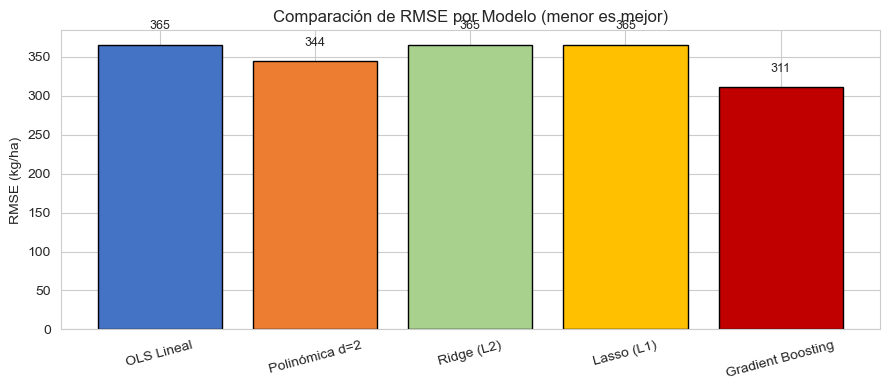

In [19]:
# ── Celda 6b: Gráfico de barras comparativo de RMSE ─────────────────────
nombres = list(resumen.keys())
rmse_val = [resumen[k]['RMSE'] for k in nombres]
plt.figure(figsize=(9, 4))
bars = plt.bar(nombres, rmse_val, edgecolor='black',
               color=['#4472C4', '#ED7D31', '#A9D18E', '#FFC000', '#C00000'])
plt.ylabel('RMSE (kg/ha)')
plt.title('Comparación de RMSE por Modelo (menor es mejor)')
for bar, val in zip(bars, rmse_val):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,.0f}', ha='center', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('comparacion_rmse.png', dpi=120, bbox_inches='tight')
plt.show()

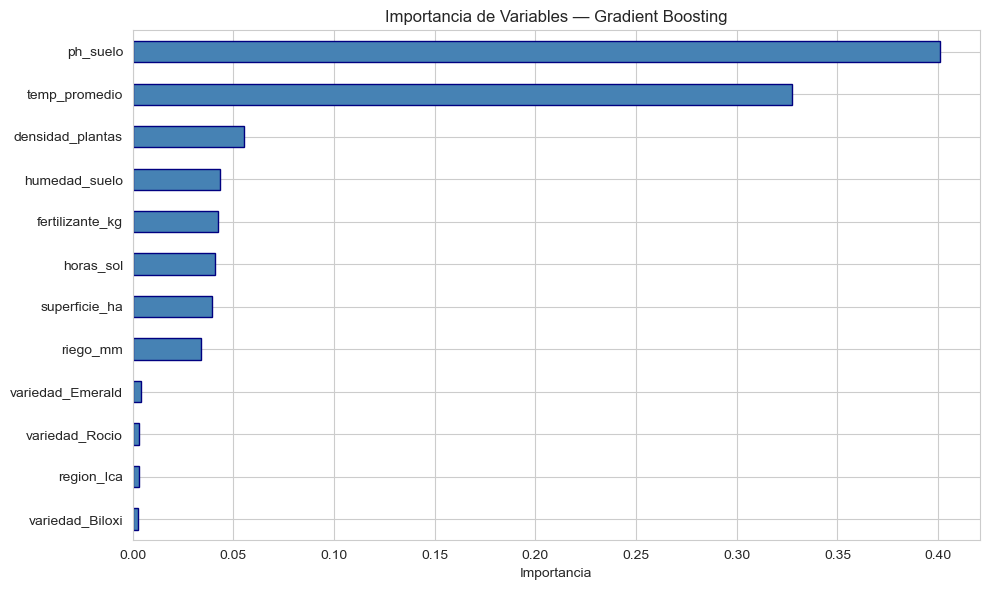

TOP 5 variables más importantes:
ph_suelo            0.4008
temp_promedio       0.3273
densidad_plantas    0.0551
humedad_suelo       0.0431
fertilizante_kg     0.0422
dtype: float64


In [20]:
# ── Celda 6c: Importancia de variables del mejor modelo (Gradient Boosting) ──
modelo_gbr = pipe_gbr.named_steps['model']
feat_num = col_numericas
feat_cat = (pipe_gbr.named_steps['pre']
            .named_transformers_['cat']
            .named_steps['encoder']
            .get_feature_names_out(col_categoricas).tolist())
all_features = feat_num + feat_cat
importancias = pd.Series(modelo_gbr.feature_importances_, index=all_features)
importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importancias.head(12).plot(kind='barh', ax=ax, color='steelblue', edgecolor='navy')
ax.set_title('Importancia de Variables — Gradient Boosting')
ax.set_xlabel('Importancia')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=120, bbox_inches='tight')
plt.show()
print('TOP 5 variables más importantes:')
print(importancias.head(5).round(4))

### Observaciones sobre la comparación y selección de modelos

- El modelo con mejor RMSE en test coincide con el mejor en validación cruzada: el Gradient Boosting Regressor es el mejor tanto en el conjunto de prueba (RMSE ≈ 311 kg/ha, R² ≈ 0.65) como en la validación cruzada 5-fold (RMSE_CV ≈ 326 ± 11 kg/ha, R² ≈ 0.61).
- Los modelos lineales (OLS, Ridge, Lasso) quedan bastante por detrás (RMSE ≈ 365, R² ≈ 0.52). La regresión polinómica de grado 2 mejora algo (RMSE ≈ 344, R² ≈ 0.57), pero el grado 3 sobreajusta (R² negativo en test), lo que muestra que subir el grado sin control no es la solución.
- Las 3 variables más influyentes según la importancia del Gradient Boosting son ph_suelo (≈ 0.40), temp_promedio (≈ 0.33) y, muy por detrás, densidad_plantas (≈ 0.06). Esto tiene pleno sentido agronómico: el pH y la temperatura son las variables con un óptimo fisiológico para el arándano, y juntas explican cerca del 73% de la importancia del modelo.
- El Gradient Boosting supera a la regresión lineal porque captura las relaciones no lineales en forma de campana: al construir árboles poco profundos de manera secuencial, aprende que el rendimiento cae tanto si el pH es muy bajo como si es muy alto, algo que una recta (OLS/Ridge/Lasso) no puede representar.
- Los efectos lineales (sol, humedad, densidad) los capta cualquier modelo; la ventaja decisiva está en modelar bien el pH y la temperatura.

## 7. Conclusiones e Interpretación de Negocio

- Se selecciona el Gradient Boosting Regressor como modelo final: obtuvo el menor RMSE (≈ 311 kg/ha) y el mayor R² (≈ 0.65) en prueba, resultado confirmado por la validación cruzada (RMSE_CV ≈ 326 kg/ha, R² ≈ 0.61), y supera con claridad a los modelos lineales (OLS/Ridge/Lasso, R² ≈ 0.52) y a la regresión polinómica de grado 2 (R² ≈ 0.57).
- Su ventaja está en capturar la relación en forma de campana del pH del suelo (≈ 40% de importancia) y la temperatura promedio (≈ 33%), las dos variables con un valor óptimo (pH ≈ 5.5 y ≈ 20 °C), mientras que la densidad de plantas, la humedad, el fertilizante y las horas de sol quedan en un segundo plano con efectos más lineales y de menor peso.
- Para AndinaSense el modelo permite estimar por adelantado el rendimiento de cada parcela a partir de sus lecturas de sensores y, con ello, planificar la cosecha, proyectar ingresos y detectar parcelas de bajo desempeño antes de la campaña.
- Como los factores dominantes son manejables, conviene priorizar las intervenciones de mayor retorno (corregir el pH del suelo con enmiendas y gestionar el microclima o temperatura donde sea posible) antes que aumentar riego o fertilizante, que mostraron un efecto marginal menor.
- Los valores faltantes y atípicos de los sensores se imputaron con la mediana o moda, lo que introduce cierto sesgo, y el modelo asume que las relaciones observadas se mantienen en campañas futuras; ante cambios de variedad, clima o manejo conviene reentrenar y validar con datos reales de campo.

## 8. Anexo de Prompts
Nota: los prompts de generación del dataset sintético (compartido por los
Informes 3 a 6) se documentan en el anexo consolidado del proyecto.

| N° | Objetivo | Herramienta | Texto del prompt | Resultado / uso | Validación del equipo |
|----|----------|-------------|------------------|-----------------|-----------------------|
| P-03.1 | Armar el preprocesamiento sin fuga de datos hacia el conjunto de prueba | Claude Sonnet 4.5 | *"Quiero encapsular el preprocesamiento en un ColumnTransformer dentro de un Pipeline para evitar data leakage: imputar la mediana y estandarizar las numéricas, e imputar la moda con OneHotEncoder en las categóricas region y variedad. Necesito que el ajuste use únicamente X_train y que el mismo objeto transforme X_test sin volver a ajustarse, para que la validación sea honesta."* | Se adoptó la estructura Pipeline(preprocessor + modelo) de las Celdas 3c-4, con el preprocesamiento ajustado solo sobre el entrenamiento | Verifiqué que el fit del pipeline recibe solo X_train y que X_test se transforma sin reajuste, revisando que no hubiera estadísticos del test filtrados al preprocesador |
| P-03.2 | Elegir modelos coherentes con la estructura no lineal del target | Claude Sonnet 4.5 | *"Mi variable objetivo tiene efectos no lineales en forma de campana (pH y temperatura con un óptimo fisiológico) además de efectos lineales de otras variables. Sabiendo esto, ¿qué modelos debo comparar más allá de OLS, Ridge y Lasso para que la comparación sea justa y no penalice de entrada a los lineales? Justifícame por qué cada uno podría o no capturar la campana."* | Se incluyeron regresión polinómica y Gradient Boosting; este último resultó el mejor (R² ≈ 0.65) al modelar la caída del rendimiento a ambos lados del óptimo | Confirmé la elección con los resultados: los lineales quedaron en R² ≈ 0.52 y el grado 3 polinómico sobreajustó, lo que respaldó a Gradient Boosting como el adecuado |
| P-03.3 | Extraer e interpretar la importancia de variables con sentido agronómico | Claude Sonnet 4.5 | *"Necesito extraer feature_importances_ de un GradientBoostingRegressor que está dentro de un Pipeline con OneHotEncoder, y mapear correctamente los nombres de columna transformados a las variables originales. Además quiero interpretar por qué el pH y la temperatura pueden tener correlación lineal negativa con el rendimiento pero salir como las más importantes en un modelo no lineal."* | Se usó get_feature_names_out para nombrar las variables (Celda 6c); pH (≈ 0.40) y temperatura (≈ 0.33) resultaron las más influyentes, coherente con su óptimo fisiológico | Contrasté que la importancia coincidiera con los scatter en forma de campana y con la agronomía del arándano, descartando que fuera un artefacto del modelo |
| P-03.4 | Diagnosticar advertencias y resultados anómalos durante el ajuste | Claude Sonnet 4.5 | *"Durante el modelado me aparecieron dos situaciones que quiero entender antes de reportarlas: un ConvergenceWarning al ajustar Lasso, y un R² negativo con RMSE enorme en test en la regresión polinómica de grado 3 pese a un buen train. Explícame si son errores de código o comportamiento esperado, y cómo corregir el primero sin distorsionar el modelo."* | Claude aclaró que el aviso de Lasso se resuelve subiendo max_iter o usando LassoCV, y que el R² negativo del grado 3 es sobreajuste, no un bug; ambos se documentaron en la tabla y las observaciones | Comprobé que tras subir max_iter los coeficientes y el RMSE de Lasso se mantuvieran estables, y confirmé el sobreajuste comparando train vs test en el grado 3 |